In [1]:
print("hello")

hello


In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# See first rows
print("df head : \n",df.head())
print("df describe \n: ",df.describe())
print("df info \n: ",df.info())

df head : 
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
df describe 
:               MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.0000

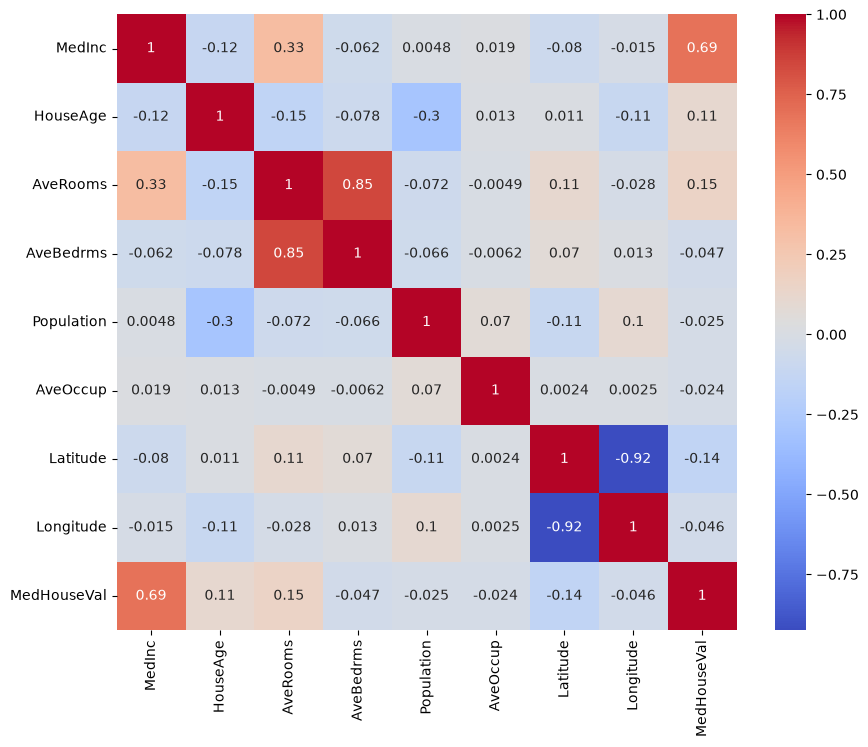

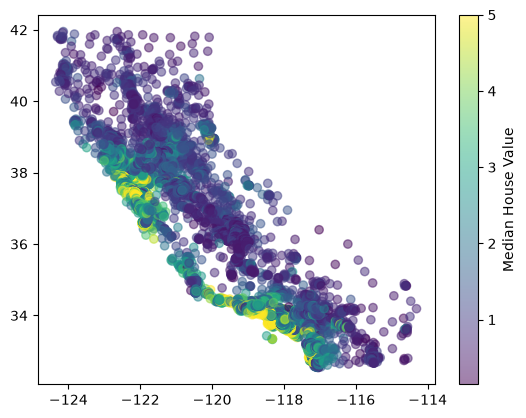

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# Scatter plot: location vs house value
plt.scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"], cmap="viridis", alpha=0.5)
plt.colorbar(label="Median House Value")
plt.show()


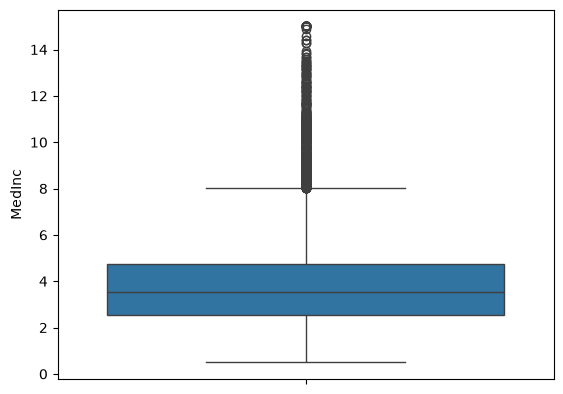

Outliers in MedInc: 345


In [3]:
import numpy as np


# Example: Check outliers in 'MedInc'
sns.boxplot(df['MedInc'])
plt.show()

# Z-score method
z_scores = np.abs((df['MedInc'] - df['MedInc'].mean()) / df['MedInc'].std())
outliers = df[z_scores > 3]
print(f"Outliers in MedInc: {len(outliers)}")

In [4]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df['MedInc_scaled'] = scaler.fit_transform(df[['MedInc']])
print(df['MedInc_scaled'])

0        2.197582
1        2.186664
2        1.707732
3        0.967177
4        0.142854
           ...   
20635   -0.905796
20636   -0.448655
20637   -0.841709
20638   -0.765007
20639   -0.525816
Name: MedInc_scaled, Length: 20640, dtype: float64


In [5]:
df['MedInc_log'] = np.log1p(df['MedInc'])
print(df['MedInc_log'])

0        2.232720
1        2.230165
2        2.111110
3        1.893579
4        1.578195
           ...   
20635    0.940124
20636    1.268861
20637    0.993252
20638    1.053336
20639    1.220417
Name: MedInc_log, Length: 20640, dtype: float64


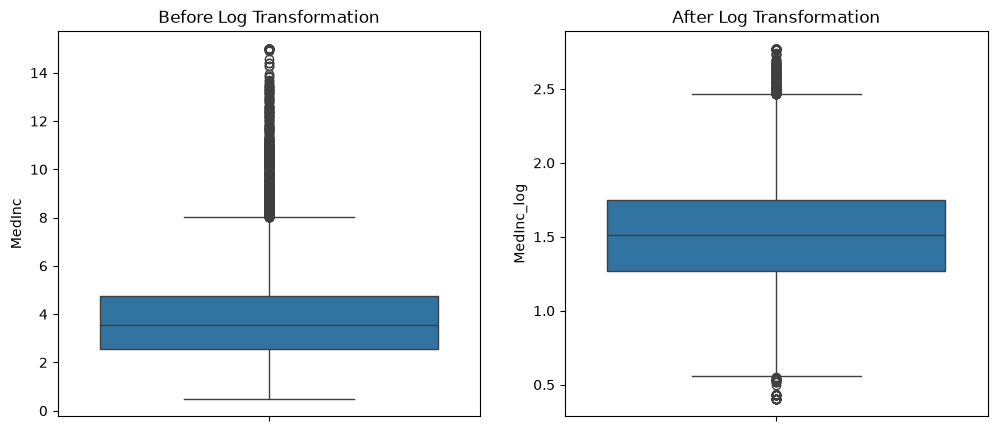

In [6]:
#Log Transformation Visualization

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(df['MedInc'])
plt.title("Before Log Transformation")

plt.subplot(1,2,2)
sns.boxplot(df['MedInc_log'])
plt.title("After Log Transformation")

plt.show()

## Before Transformation
#High variance, High skewness (long right tail), Non-Gaussian distribution

## After Transformation
#Reduced variance, Reduced skewness, More Gaussian-like distribution (distribution closer to normal)

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Intercept: -36.435131401067
Coefficients: [ 3.20410068e-01  1.00278591e-02 -1.31589452e-01  8.23551689e-01
 -3.46339128e-06 -3.48989081e-03 -4.11571557e-01 -4.25633503e-01
  1.46987209e-01  3.63896695e-01]
RMSE: 0.746
MAE: 0.535
R² Score: 0.575


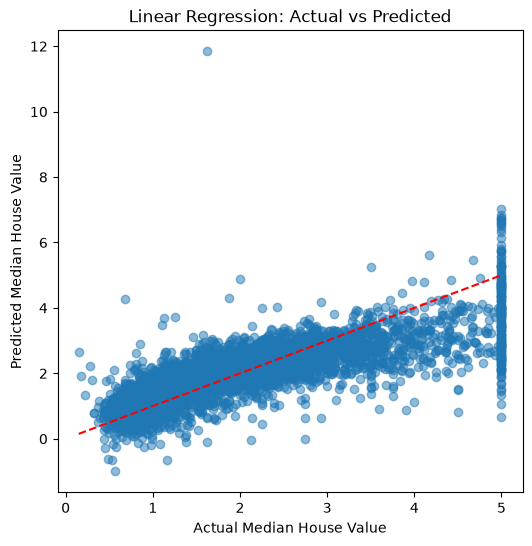

In [8]:
#TESTING LINEAR REGRESSION MODEL
from sklearn.linear_model import LinearRegression

# Initialize and train the model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Intercept:", lin_reg.intercept_)
print("Coefficients:", lin_reg.coef_)

y_pred = lin_reg.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R² Score: {r2:.3f}")

#plot predicted vs actual prices
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Linear Regression: Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # reference line
plt.show()

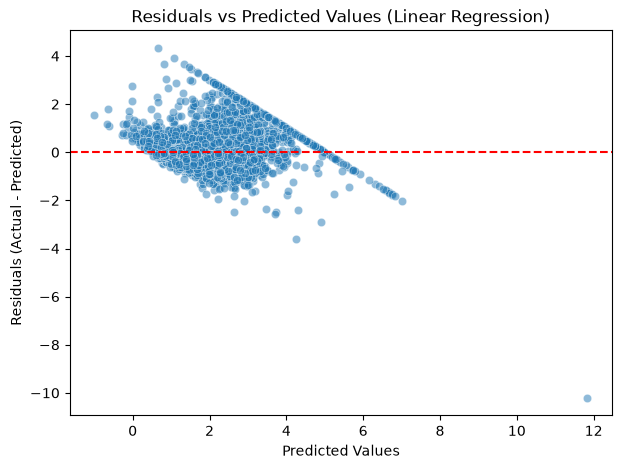

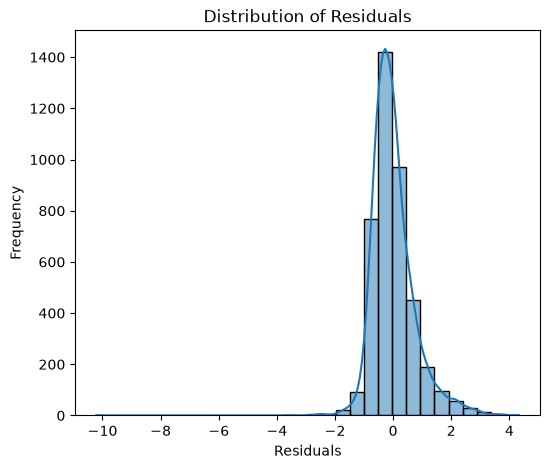

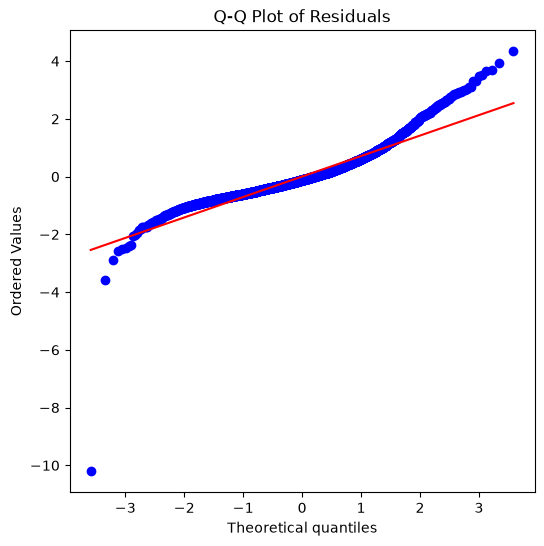

In [9]:
import pandas as pd

residuals = y_test - y_pred

#Residual vs Predicted values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted Values (Linear Regression)")
plt.show()

plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [10]:
#Random Forest Regressor Model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the model
rf = RandomForestRegressor(
    n_estimators=200,       # number of trees
    max_depth=None,         # let trees expand fully
    min_samples_split=2,    
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
# Train the model
rf.fit(X_train, y_train)
# Make predictions
y_pred_rf = rf.predict(X_test)
# Evaluate the model
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf) 
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Regressor Performance:")
print(f"RMSE: {rmse_rf:.3f}")
print(f"MAE: {mae_rf:.3f}")
print(f"R² Score: {r2_rf:.3f}")

Random Forest Regressor Performance:
RMSE: 0.504
MAE: 0.327
R² Score: 0.806


In [11]:
#Comparison with Linear Regression
print("\nComparison with Linear Regression:")
print(f"Linear Regression RMSE: {rmse:.3f} vs Random Forest RMSE: {rmse_rf:.3f}")
print(f"Linear Regression MAE: {mae:.3f} vs Random Forest MAE: {mae_rf:.3f}")
print(f"Linear Regression R²: {r2:.3f} vs Random Forest R²: {r2_rf:.3f}")


Comparison with Linear Regression:
Linear Regression RMSE: 0.746 vs Random Forest RMSE: 0.504
Linear Regression MAE: 0.535 vs Random Forest MAE: 0.327
Linear Regression R²: 0.575 vs Random Forest R²: 0.806


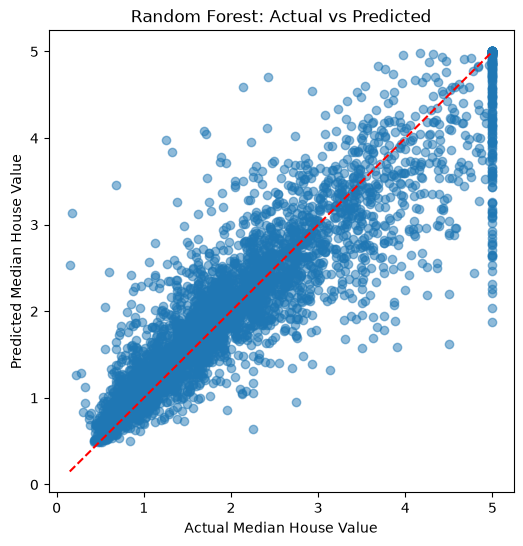

In [12]:
#Plots for Random Forest Regressor
import matplotlib.pyplot as plt
# Predicted vs Actual plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

MedInc_log       0.185254
MedInc_scaled    0.182817
MedInc           0.161170
AveOccup         0.137613
Latitude         0.088243
Longitude        0.087907
HouseAge         0.053887
AveRooms         0.043776
Population       0.030144
AveBedrms        0.029189
dtype: float64


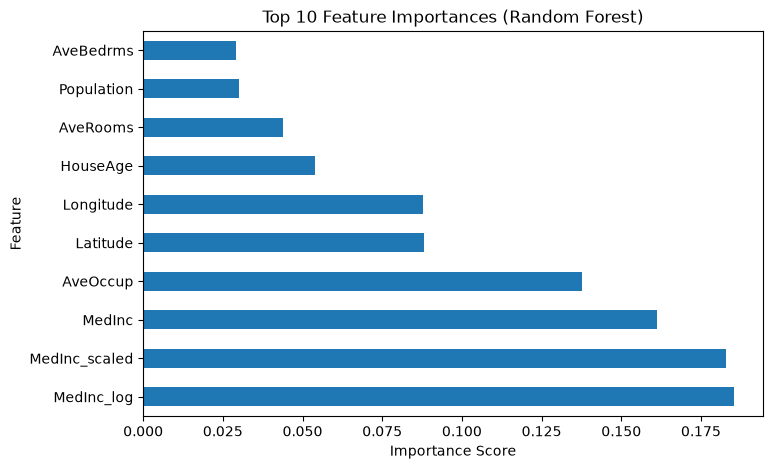

In [13]:
#Feature Importance Plot
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importance)

feature_importance.head(10).plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()